This notebook was used to predict the knockdown changes in distal peaks and is in its original development stage. Predictions can be performed much easier in the multiDGD package.

In [ ]:
import argparse
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import anndata as ad
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
from scipy.sparse import csr_matrix
from accelerate import Accelerator
from sklearn.model_selection import train_test_split
from epiGen_models import load_pretrain, sparse_scipy_to_tensor, XDict, ATACformer
from utils import load_model, finetune_batch_embedding, simulate_perturbation

plt.rcParams.update({'font.size': 8})
plt.rcParams['figure.dpi'] = 300

/home/yuliyi/anaconda3/envs/pyt/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def parse_args():
    """Parse command line arguments for hyperparameters and paths."""
    parser = argparse.ArgumentParser(description="Run epiGen.")
    parser.add_argument('--data_dir', nargs='?', default='/path',
                        help='Input data path.')
    parser.add_argument('--model_dir', nargs='?', default='/path/model',
                        help='Directory to save the trained model.')
    parser.add_argument('--seed', type=int, default=0, help='Random seed for reproducibility.')
    parser.add_argument('--lr', type=float, default=0.001, help='Base learning rate.')
    parser.add_argument('--embed_dim', type=int, default=64, help='Dimension of the batch embedding.')
    parser.add_argument('--n_epoch', type=int, default=500, help='Total number of training epochs.')
    parser.add_argument('--stopping_steps', type=int, default=100,
                        help='Patience (number of epochs) for early stopping.')
    parser.add_argument('--batch_size', type=int, default=128, help='Input batch size for training.')
    return parser.parse_args()
    
args = parse_args()
# seed
random.seed(args.seed)
os.environ['PYTHONHASHSEED'] = str(args.seed)
np.random.seed(args.seed)
torch.manual_seed(args.seed)
torch.cuda.manual_seed(args.seed)
torch.cuda.manual_seed_all(args.seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
accelerator = Accelerator()

In [ ]:
preprocess_dir = "/pool2/tmp/yuliyi/ATACformer/data/hichip/preprocess/"
if not os.path.exists(preprocess_dir):
    os.makedirs(preprocess_dir)
result_dir = "/pool2/tmp/yuliyi/ATACformer/data/hichip/result/"
if not os.path.exists(result_dir):
    os.makedirs(result_dir)
data_dir = args.data_dir
model_dir = args.model_dir

## load data and model

### load data

In [ ]:
peaks_chr12 = np.loadtxt(data_dir + f"/atac_data/peaks_chr12.bed", delimiter="\t", dtype=str)
ref_df_chr12 = pd.DataFrame(peaks_chr12, columns=['Chromosome', 'Start', 'End'])
ref_df_chr12['Start'] = ref_df_chr12['Start'].astype(int)
ref_df_chr12['End'] = ref_df_chr12['End'].astype(int)

peaks_chr6 = np.loadtxt(data_dir + f"/atac_data/peaks_chr6.bed", delimiter="\t", dtype=str)
ref_df_chr6 = pd.DataFrame(peaks_chr6, columns=['Chromosome', 'Start', 'End'])
ref_df_chr6['Start'] = ref_df_chr6['Start'].astype(int)
ref_df_chr6['End'] = ref_df_chr6['End'].astype(int)

peaks_chr5 = np.loadtxt(data_dir + f"/atac_data/peaks_chr5.bed", delimiter="\t", dtype=str)
ref_df_chr5 = pd.DataFrame(peaks_chr5, columns=['Chromosome', 'Start', 'End'])
ref_df_chr5['Start'] = ref_df_chr5['Start'].astype(int)
ref_df_chr5['End'] = ref_df_chr5['End'].astype(int)

peaks_chr4 = np.loadtxt(data_dir + f"/atac_data/peaks_chr4.bed", delimiter="\t", dtype=str)
ref_df_chr4 = pd.DataFrame(peaks_chr4, columns=['Chromosome', 'Start', 'End'])
ref_df_chr4['Start'] = ref_df_chr4['Start'].astype(int)
ref_df_chr4['End'] = ref_df_chr4['End'].astype(int)

peaks_chr2 = np.loadtxt(data_dir + f"/atac_data/peaks_chr2.bed", delimiter="\t", dtype=str)
ref_df_chr2 = pd.DataFrame(peaks_chr2, columns=['Chromosome', 'Start', 'End'])
ref_df_chr2['Start'] = ref_df_chr2['Start'].astype(int)
ref_df_chr2['End'] = ref_df_chr2['End'].astype(int)

peaks_chr10 = np.loadtxt(data_dir + f"/atac_data/peaks_chr10.bed", delimiter="\t", dtype=str)
ref_df_chr10 = pd.DataFrame(peaks_chr10, columns=['Chromosome', 'Start', 'End'])
ref_df_chr10['Start'] = ref_df_chr10['Start'].astype(int)
ref_df_chr10['End'] = ref_df_chr10['End'].astype(int)

gene_id = np.loadtxt(data_dir + '/rna_data/rna_cellplm_genes.txt', dtype=str)
gene_name = np.loadtxt(data_dir + '/rna_data/rna_cellplm_gene_names.txt', dtype=str)
rna_ref_df = pd.DataFrame({'gene_id': gene_id, 'gene_name': gene_name})

rna_list = ad.read_h5ad(data_dir + "/rna_data/rna_independence_t_cell.h5ad")
celltype = rna_list.obs.celltype.values
ct_a = rna_list.obs.ct_a.values
batch_info = rna_list.obs.batch.tolist()
batch_int, uniques = pd.factorize(batch_info)
batch_int = np.array(list(map(lambda x: x + 222, batch_int))).astype(int)
print(f"batch size: {len(uniques)}")
mapping = dict(zip(uniques, range(222, 222+len(uniques))))
print(f"batch mapping: {mapping}")
sc.pp.normalize_total(rna_list, 1e4)
gene_list = rna_list.var_names.tolist()

batch size: 9
batch mapping: {'GSM7470306_JC4': 222, 'GSM7470307_JC5': 223, 'GSM7470308_JC6': 224, 'GSM7470309_JC7': 225, 'GSM7470310_JC8': 226, 'GSM7470311_JC9': 227, 'GSM7470312_JC10': 228, 'GSM7470313_JC11': 229, 'GSM7470314_JC12': 230}


/tmp/ipykernel_726704/3921881968.py:44: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  batch_int, uniques = pd.factorize(batch_info)
/tmp/ipykernel_726704/3921881968.py:49: FutureWarning: The specified parameters ('target_sum',) are no longer positional. Please specify them like `target_sum=10000.0`
  sc.pp.normalize_total(rna_list, 1e4)


## define functions

In [ ]:
def get_gene_ids(gene_name):
    gene_id = rna_ref_df[rna_ref_df["gene_name"] == gene_name]["gene_id"].values[0]
    gene_idx = np.where(rna_ref_df["gene_name"] == gene_name)[0][0]
    return gene_id, gene_idx


def find_closest_peak(gene_location, sub_df):
    chrom = int(gene_location.split(":")[0].split("chr")[1])
    start = gene_location.split(":")[1].split("-")[0]
    end = gene_location.split(":")[1].split("-")[1]
    # sub_df = ref_df[ref_df["Chromosome"] == chrom]
    # now find the peaks that contain the gene
    sub_df = sub_df[
        (((sub_df["Start"]) <= int(start)) & (sub_df["End"] >= int(end)))
        | (  # peak contains gene
            (sub_df["Start"] >= int(start)) & (sub_df["End"] <= int(end))
        )
        | (  # gene contains peak
            (sub_df["Start"] <= int(start)) & (sub_df["End"] >= int(start))
        )
        | (  # peak starts before gene
            (sub_df["Start"] <= int(end)) & (sub_df["End"] >= int(end))
        )  # peak ends after gene
    ]
    closest_peak = list(sub_df.index.values)
    return closest_peak


def find_closest_start_and_end(chrom, window_start, window_end, sub_df):
    # sub_df = ref_df[ref_df["Chromosome"] == int(chrom.split("chr")[-1])]
    start_distances = np.abs(sub_df["Start"] - window_start)
    end_distances = np.abs(sub_df["End"] - window_end)
    start_idx = np.argmin(start_distances)
    end_idx = np.argmin(end_distances)
    return sub_df.index.values[start_idx], sub_df.index.values[end_idx]


def plot_gel(heatmap, celltypes, peaks, gene_name, gene_loc):
    df_heatmap_1 = pd.DataFrame(
        heatmap,
        columns=peaks,
        index=celltypes,
    )
    df_heatmap_1 = df_heatmap_1.sort_index()
    return df_heatmap_1


def insilico_hichip(
    df, celltypes_of_choice, bins, window_size=10000, norm=True, use_abs=True
):
    # select data only for the cell types of interest
    df_cell = df.copy()[df.index.isin(celltypes_of_choice)]
    df_cell = df_cell.dropna()
    # get average and std of predicted differences
    df_cell_avg = df_cell.mean()
    df_cell_std = df_cell.std()

    # create data for evenly spaced bins of 10 kilobases
    bp_location_starts = []
    binned_kb_avg = []
    binned_kb_std = []
    # first go through the peaks
    for i in range(0, len(df_cell_avg)):
        location = df_cell_avg.index[i]
        start = int(location.split("-")[1])
        end = int(location.split("-")[2])
        # now loop through the bins
        for j in range(start, end, window_size):
            bp_location_starts.append(j)
            if use_abs:
                binned_kb_avg.append(abs(df_cell_avg[i]))
            else:
                binned_kb_avg.append(df_cell_avg[i])
            binned_kb_std.append(df_cell_std[i])
        # if j was still smaller than the end, add the end
        if j < end:
            bp_location_starts.append(end)
            if use_abs:
                binned_kb_avg.append(abs(df_cell_avg[i]))
            else:
                binned_kb_avg.append(df_cell_avg[i])
            binned_kb_std.append(df_cell_std[i])
        # if the next peak is not directly after this one, add zeros until the begin of the next peak
        if i < len(df_cell_avg) - 1:
            next_start = int(df_cell_avg.index[i + 1].split("-")[1])
            if end + window_size < next_start:
                for j in range(end + window_size, next_start, window_size):
                    bp_location_starts.append(j)
                    binned_kb_avg.append(0)
                    binned_kb_std.append(0)

    # normalize the values
    binned_kb_avg = np.array(binned_kb_avg)
    binned_kb_std = np.array(binned_kb_std)
    if norm:
        binned_kb_avg = (binned_kb_avg - np.min(binned_kb_avg)) / (
            np.max(binned_kb_avg) - np.min(binned_kb_avg)
        )
        binned_kb_std = (binned_kb_std - np.min(binned_kb_std)) / (
            np.max(binned_kb_std) - np.min(binned_kb_std)
        )

    # return bp_location_starts, binned_kb_avg, binned_kb_std

    # now match the binned data with the provided bins (average if multiple peaks were in one reference bin)
    binned_kb_avg_matched = []
    binned_kb_std_matched = []
    for i in range(0, len(bins)):
        # get the indices of the binned data that are in the reference bin
        if i == len(bins) - 1:
            indices = np.where(np.array(bp_location_starts) >= bins[i])[0]
        else:
            indices = np.where(
                np.logical_and(
                    np.array(bp_location_starts) >= bins[i],
                    np.array(bp_location_starts) < bins[i + 1],
                )
            )[0]
        # if there are no indices, add a zero
        if len(indices) == 0:
            # print('error')
            # print(i, bins[i], len(bins))
            binned_kb_avg_matched.append(0)
            binned_kb_std_matched.append(0)
        # if there are indices, average the values
        else:
            binned_kb_avg_matched.append(np.mean(binned_kb_avg[indices]))
            binned_kb_std_matched.append(np.mean(binned_kb_std[indices]))
            # binned_kb_avg_matched.append(np.max(binned_kb_avg[indices]))
            # binned_kb_std_matched.append(np.max(binned_kb_std[indices]))
    return bins, binned_kb_avg_matched, binned_kb_std_matched


def normalize_hichip(hichip_eis, scaling_factor=10):
    hichip_eis = (hichip_eis - np.min(hichip_eis)) / (
        np.max(hichip_eis) - np.min(hichip_eis)
    )
    return hichip_eis * scaling_factor


def prepare_df_emma(file_dir):
    df_emma = pd.read_csv(file_dir, sep=",")
    sample_names = df_emma.sample_name.unique()
    # average the positive controls
    df_pos = df_emma[df_emma.sample_name != "HCASMC_HiChIP_H3K27ac"]
    df_pos = df_pos.groupby(["position"])["EIS"].mean().reset_index()
    df_pos["sample_name"] = "positive"
    df_pos = df_pos[["position", "EIS", "sample_name"]]
    df_neg = df_emma[df_emma.sample_name == "HCASMC_HiChIP_H3K27ac"]
    df_neg["sample_name"] = "negative"
    df_neg = df_neg[["position", "EIS", "sample_name"]]
    df_emma_out = pd.concat([df_pos, df_neg])
    df_emma_out.columns = ["position", "signal", "cell type"]
    df_emma_out["std"] = 0
    df_emma_out["method"] = "HiChIP"
    return df_emma_out


from scipy.stats import spearmanr


def gene_correlation(
    gene_values,
    df,
    celltypes_of_choice,
    bins,
    window_size=10000,
    norm=True,
    use_abs=True,
):
    # select data only for the cell types of interest
    df_cell = df.copy()[df.index.isin(celltypes_of_choice)]
    df_cell = df_cell.dropna()
    # get correlation between gene and peaks (spearman)
    df_cell_corr = df_cell.apply(lambda x: 0 if np.all(x.values == x.values[0]) else spearmanr(gene_values, x.values)[0], axis=0)
    df_cell_std = df_cell.apply(lambda x: 0 if np.all(x.values == x.values[0]) else spearmanr(gene_values, x.values)[1], axis=0)

    # create data for evenly spaced bins of 10 kilobases
    bp_location_starts = []
    binned_kb_avg = []
    binned_kb_std = []
    # first go through the peaks
    for i in range(0, len(df_cell_corr)):
        location = df_cell_corr.index[i]
        start = int(location.split("-")[1])
        end = int(location.split("-")[2])
        # now loop through the bins
        for j in range(start, end, window_size):
            bp_location_starts.append(j)
            if use_abs:
                binned_kb_avg.append(abs(df_cell_corr[i]))
            else:
                binned_kb_avg.append(df_cell_corr[i])
            binned_kb_std.append(df_cell_std[i])
        # if j was still smaller than the end, add the end
        if j < end:
            bp_location_starts.append(end)
            if use_abs:
                binned_kb_avg.append(abs(df_cell_corr[i]))
            else:
                binned_kb_avg.append(df_cell_corr[i])
            binned_kb_std.append(df_cell_std[i])
        # if the next peak is not directly after this one, add zeros until the begin of the next peak
        if i < len(df_cell_corr) - 1:
            next_start = int(df_cell_corr.index[i + 1].split("-")[1])
            if end + window_size < next_start:
                for j in range(end + window_size, next_start, window_size):
                    bp_location_starts.append(j)
                    binned_kb_avg.append(0)
                    binned_kb_std.append(0)

    # normalize the values
    binned_kb_avg = np.array(binned_kb_avg)
    binned_kb_std = np.array(binned_kb_std)
    if norm:
        binned_kb_avg = (binned_kb_avg - np.min(binned_kb_avg)) / (
            np.max(binned_kb_avg) - np.min(binned_kb_avg)
        )
        binned_kb_std = (binned_kb_std - np.min(binned_kb_std)) / (
            np.max(binned_kb_std) - np.min(binned_kb_std)
        )

    # return bp_location_starts, binned_kb_avg, binned_kb_std

    # now match the binned data with the provided bins (average if multiple peaks were in one reference bin)
    binned_kb_avg_matched = []
    binned_kb_std_matched = []
    for i in range(0, len(bins)):
        # get the indices of the binned data that are in the reference bin
        if i == len(bins) - 1:
            indices = np.where(np.array(bp_location_starts) >= bins[i])[0]
        else:
            indices = np.where(
                np.logical_and(
                    np.array(bp_location_starts) >= bins[i],
                    np.array(bp_location_starts) < bins[i + 1],
                )
            )[0]
        # if there are no indices, add a zero
        if len(indices) == 0:
            # print('error')
            # print(i, bins[i], len(bins))
            binned_kb_avg_matched.append(0)
            binned_kb_std_matched.append(0)
        # if there are indices, average the values
        else:
            binned_kb_avg_matched.append(np.mean(binned_kb_avg[indices]))
            binned_kb_std_matched.append(np.mean(binned_kb_std[indices]))
            # binned_kb_avg_matched.append(np.max(binned_kb_avg[indices]))
            # binned_kb_std_matched.append(np.max(binned_kb_std[indices]))
    return bins, binned_kb_avg_matched, binned_kb_std_matched


def plot_roc_curves(df_c, df_p, c_1, c_2, p_1, p_2, mode="prediction"):
    # now make ROC curves for the dgd predictions
    from sklearn.metrics import roc_curve, auc

    pos_color = "cornflowerblue"
    neg_color = "lightcoral"
    correction_color = "slategray"

    # drop duplicates
    df_c = df_c.drop_duplicates()
    df_p = df_p.drop_duplicates()

    # create 2 subplots
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
    # adjust spacing
    fig.subplots_adjust(wspace=0.9)

    # first get the values for the same positions
    x, y = df_c[df_c["cell type"] == c_1], df_p[df_p["cell type"] == p_1]
    intersect = list(set(x["position"].values).intersection(set(y["position"].values)))
    x, y = (
        x[x["position"].isin(intersect)]["signal"],
        y[y["position"].isin(intersect)]["signal"],
    )
    fpr, tpr, thresholds = roc_curve(x, y)
    auprc = auc(fpr, tpr)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    ax[0].plot(
        fpr, tpr, pos_color, label=f"HiChIP T\nAUPRC = {np.round(auprc, 3)}"
    )

    x, y = df_c[df_c["cell type"] == c_2], df_p[df_p["cell type"] == p_1]
    intersect = list(set(x["position"].values).intersection(set(y["position"].values)))
    x, y = (
        x[x["position"].isin(intersect)]["signal"],
        y[y["position"].isin(intersect)]["signal"],
    )
    fpr, tpr, thresholds = roc_curve(x, y)
    auprc = auc(fpr, tpr)
    ax[0].plot(
        fpr,
        tpr,
        neg_color,
        label=f"HiChIP HCASMC (neg control)\nAUPRC = {np.round(auprc, 3)}",
    )
    ax[0].axline((min(fpr), min(tpr)), slope=1, color="grey", linestyle=":")
    ax[0].set_xlabel("False positive rate")
    ax[0].set_ylabel("True positive rate")
    if mode == "prediction":
        ax[0].set_title("DGD prediction ({})".format(p_1))
    else:
        ax[0].set_title("Baseline correlation ({})".format(p_1))
    ax[0].legend(
        bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0, frameon=False
    )

    x, y = df_c[df_c["cell type"] == c_1], df_p[df_p["cell type"] == p_2]
    intersect = list(set(x["position"].values).intersection(set(y["position"].values)))
    x, y = (
        x[x["position"].isin(intersect)]["signal"],
        y[y["position"].isin(intersect)]["signal"],
    )
    fpr, tpr, thresholds = roc_curve(x, y)
    auprc = auc(fpr, tpr)
    ax[1].plot(
        fpr, tpr, pos_color, label=f"HiChIP T\nAUPRC = {np.round(auprc, 3)}"
    )

    x, y = df_c[df_c["cell type"] == c_2], df_p[df_p["cell type"] == p_2]
    intersect = list(set(x["position"].values).intersection(set(y["position"].values)))
    x, y = (
        x[x["position"].isin(intersect)]["signal"],
        y[y["position"].isin(intersect)]["signal"],
    )
    fpr, tpr, thresholds = roc_curve(x, y)
    auprc = auc(fpr, tpr)
    ax[1].plot(
        fpr,
        tpr,
        neg_color,
        label=f"HiChIP HCASMC (neg control)\nAUPRC = {np.round(auprc, 3)}",
    )
    ax[1].axline((min(fpr), min(tpr)), slope=1, color="grey", linestyle=":")
    ax[1].set_xlabel("False positive rate")
    ax[1].set_ylabel("True positive rate")
    if mode == "prediction":
        ax[1].set_title("DGD prediction ({})".format(p_2))
    else:
        ax[1].set_title("Baseline correlation ({})".format(p_2))
    ax[1].legend(
        bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0, frameon=False
    )
    plt.show()

    return optimal_threshold


@accelerator.on_local_main_process
def evaluate_perturbation(model, test_loader, rna_test, batch_test, device):
    model.eval()
    yy_score = []
    with torch.no_grad():
        for batch_cell in test_loader:
            batch_cell_idx = batch_cell[0].cpu()
            cell_rna = XDict({'x_seq': rna_test.index_select(0, torch.IntTensor(batch_cell_idx).type(torch.long)).to(device),
                              'batch': batch_test[batch_cell_idx].to(device)})
            outs = model(cell_rna)[0]
            yy_score.append(outs.reshape(len(batch_cell_idx), model.peak_size).detach().cpu().numpy())
            del cell_rna, outs
            torch.cuda.empty_cache()
        a_preds = np.concatenate(yy_score, axis=0)
        del yy_score
        torch.cuda.empty_cache()
        return a_preds

# 1. Perturbation for target gene

We will go through this by gene, and produce our silencing prediction changes for each gene, including a baseline from simple correlation metrics.

## Gene: CD69

In [7]:
# define the gene of interest and its location
gene_name = "CD69"
gene_location = "chr12:9752486-9760901"

# load the ground truth data (experimental HiChIP)
file_dir = preprocess_dir + "EIS_signal_" + gene_name + "_promoter.hg38.csv"
# define where the gene of interest is in the data (and its location)
gene_id, gene_idx = get_gene_ids(gene_name)
peak_ids = find_closest_peak(gene_location, ref_df_chr12)
print(
    "Gene ID is {} at index {}, peak positions are {}".format(
        gene_id, gene_idx, peak_ids
    )
)

Gene ID is ENSG00000110848 at index 2119, peak positions are [4630, 4631, 4632, 4633, 4634, 4635, 4636, 4637]


In [8]:
#print the gene locations of the two closest peak_ids (to see whether the data even covers the gene)
print("The closest peaks are located at:")
for peak_id in peak_ids:
    print(peak_id, ref_df_chr12.iloc[peak_id].values)

The closest peaks are located at:
4630 ['chr12' 9752998 9753696]
4631 ['chr12' 9755095 9755258]
4632 ['chr12' 9756098 9756433]
4633 ['chr12' 9757709 9757928]
4634 ['chr12' 9758200 9758361]
4635 ['chr12' 9758448 9759392]
4636 ['chr12' 9760168 9760410]
4637 ['chr12' 9760525 9761256]


### perturbation

In [ ]:
device = accelerator.device
chr = 'chr12'
atac_list = ad.read_h5ad(data_dir + f"/atac_data/atac_{chr}_independence_t_cell.h5ad")
gene_ensembl, _ = get_gene_ids(gene_name)
PRETRAIN_VERSION = '20230926_85M'
cellplm = load_pretrain(PRETRAIN_VERSION, model_dir)

peak_count = len(peaks_chr12)
rna_batch = sparse_scipy_to_tensor(csr_matrix(rna_list.X.astype(float)))
_, ff_idx = train_test_split(range(len(rna_list)), test_size=0.1, random_state=args.seed)
ffset = torch.utils.data.TensorDataset(torch.IntTensor(ff_idx))
_ff = torch.utils.data.DataLoader(ffset, batch_size=args.batch_size, num_workers=4)
model = ATACformer(args, cellplm, gene_list, peak_size=peak_count)
model = load_model(model, args, chr).to(device)
model = finetune_batch_embedding(model, len(uniques), _ff, rna_batch, batch_int, device, args.lr*0.1)
for param in model.parameters():
    param.requires_grad = False

accelerator.print(f"****************perturb gene {gene_name}")
indices_of_interest_gene = np.nonzero(rna_list[:, gene_ensembl].X.toarray())[0]  # record non-zero cell index given gene in rna matrix
if len(indices_of_interest_gene) == 0:
    raise ValueError("no cell for perturbation")
else:
    print("indices_of_interest_gene:", len(indices_of_interest_gene))
rna_test_mat = rna_list[indices_of_interest_gene].copy()
rna_test_original = sparse_scipy_to_tensor(csr_matrix(rna_test_mat.X.astype(float)))
batch_test = torch.tensor(batch_int[indices_of_interest_gene], dtype=torch.int).flatten()
testset = torch.utils.data.TensorDataset(torch.IntTensor(range(len(rna_test_mat))))
_test = torch.utils.data.DataLoader(testset, batch_size=args.batch_size)

# raw prediction without perturbation
print("load model")
predictions_raw = evaluate_perturbation(model, _test, rna_test_original, batch_test, device)
print("predictions_perturb shape:", predictions_raw.shape)
torch.cuda.empty_cache()

predictions_perturb = simulate_perturbation(model, _test, rna_test_mat, rna_test_original, batch_test, gene_ensembl, gene_list, device, lr=args.lr)
print("predictions_perturb shape:", predictions_perturb.shape)
predicted_changes = predictions_perturb - predictions_raw  # δX for non-zero cell

/tmp/ipykernel_684284/801771895.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))
/pool1/yuliyi/program/ATACformer/src/pertur

****************perturb gene CD69
indices_of_interest_gene: 2670
load model
predictions_perturb shape: (2670, 46769)


/home/yuliyi/anaconda3/envs/pyt/lib/python3.9/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


predictions_perturb shape: (2670, 46769)


### analysis

In [10]:
window_length = 300000
gene_chromosome = gene_location.split(":")[0]
window_start = int(gene_location.split(":")[1].split("-")[0]) - window_length
window_end = int(gene_location.split(":")[1].split("-")[1]) + window_length
# find the closest start and end peaks to the window start and end
start_peak, end_peak = find_closest_start_and_end(gene_chromosome, window_start, window_end, ref_df_chr12)

cell_types = celltype[indices_of_interest_gene]
ct_as = ct_a[indices_of_interest_gene]
heatmap_1 = predicted_changes[:,start_peak:end_peak]

df_heatmap_1 = plot_gel(heatmap_1, ct_as, atac_list.var_names[start_peak:end_peak], gene_name, gene_location) #because it looks like a gel

In [11]:
df_heatmap_1.shape

(2670, 195)

In [12]:
cell_types_stat = df_heatmap_1.index.value_counts()
cell_types_unique = cell_types_stat.index.values
cell_types_stat

T    2670
Name: count, dtype: int64

In [13]:
# plot the response in emma's window per cell type
# so that we can compare to ground truth
# this just makes the peak windows the same

window_size = 10000

df_hichip = prepare_df_emma(file_dir)
df_pos_intersect = np.sort(df_hichip['position'].unique())

for i, ct in enumerate(cell_types_unique):
    bp_location_starts, binned_kb_avg_ct, binned_kb_std_ct = insilico_hichip(df_heatmap_1, [ct], bins=df_pos_intersect, window_size=window_size, norm=False, use_abs=True)
    df_open_closed_temp = pd.DataFrame({
        'position': bp_location_starts,
        'signal': binned_kb_avg_ct,
        'std': binned_kb_std_ct,
        'cell type': ct,
        'method': 'epiGen'
    })
    if i == 0:
        df_open_closed = df_open_closed_temp
    else:
        df_open_closed = pd.concat([df_open_closed, df_open_closed_temp], axis=0)

df_open_closed = pd.concat([df_open_closed, df_hichip], axis=0)
df_open_closed['position'] = df_open_closed['position'].values / 1e6
# reindex from 0
df_open_closed = df_open_closed.reset_index(drop=True)
# save the dataframe
df_open_closed.to_csv(
    result_dir + gene_name + "_hg38_hichip_epiGen_aligned_locations.csv", index=False
)
df_open_closed

/tmp/ipykernel_684284/257098763.py:178: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_neg["sample_name"] = "negative"
/tmp/ipykernel_684284/257098763.py:99: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  binned_kb_avg.append(abs(df_cell_avg[i]))
/tmp/ipykernel_684284/257098763.py:102: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  binned_kb_std.append(df_cell_std[i])
/tmp/ipyk

,position,signal,std,cell type,method
0,9.457404,0.000000,0.000000,T,epiGen
1,9.467404,0.000000,0.000000,T,epiGen
2,9.477404,0.000000,0.000000,T,epiGen
3,9.557404,0.000000,0.000000,T,epiGen
4,9.577404,0.000003,0.000157,T,epiGen
...,...,...,...,...,...
142,9.987401,0.145841,0.000000,negative,HiChIP
143,9.997401,0.145841,0.000000,negative,HiChIP
144,10.007401,0.875045,0.000000,negative,HiChIP
145,10.017401,0.291682,0.000000,negative,HiChIP


### baseline correlation

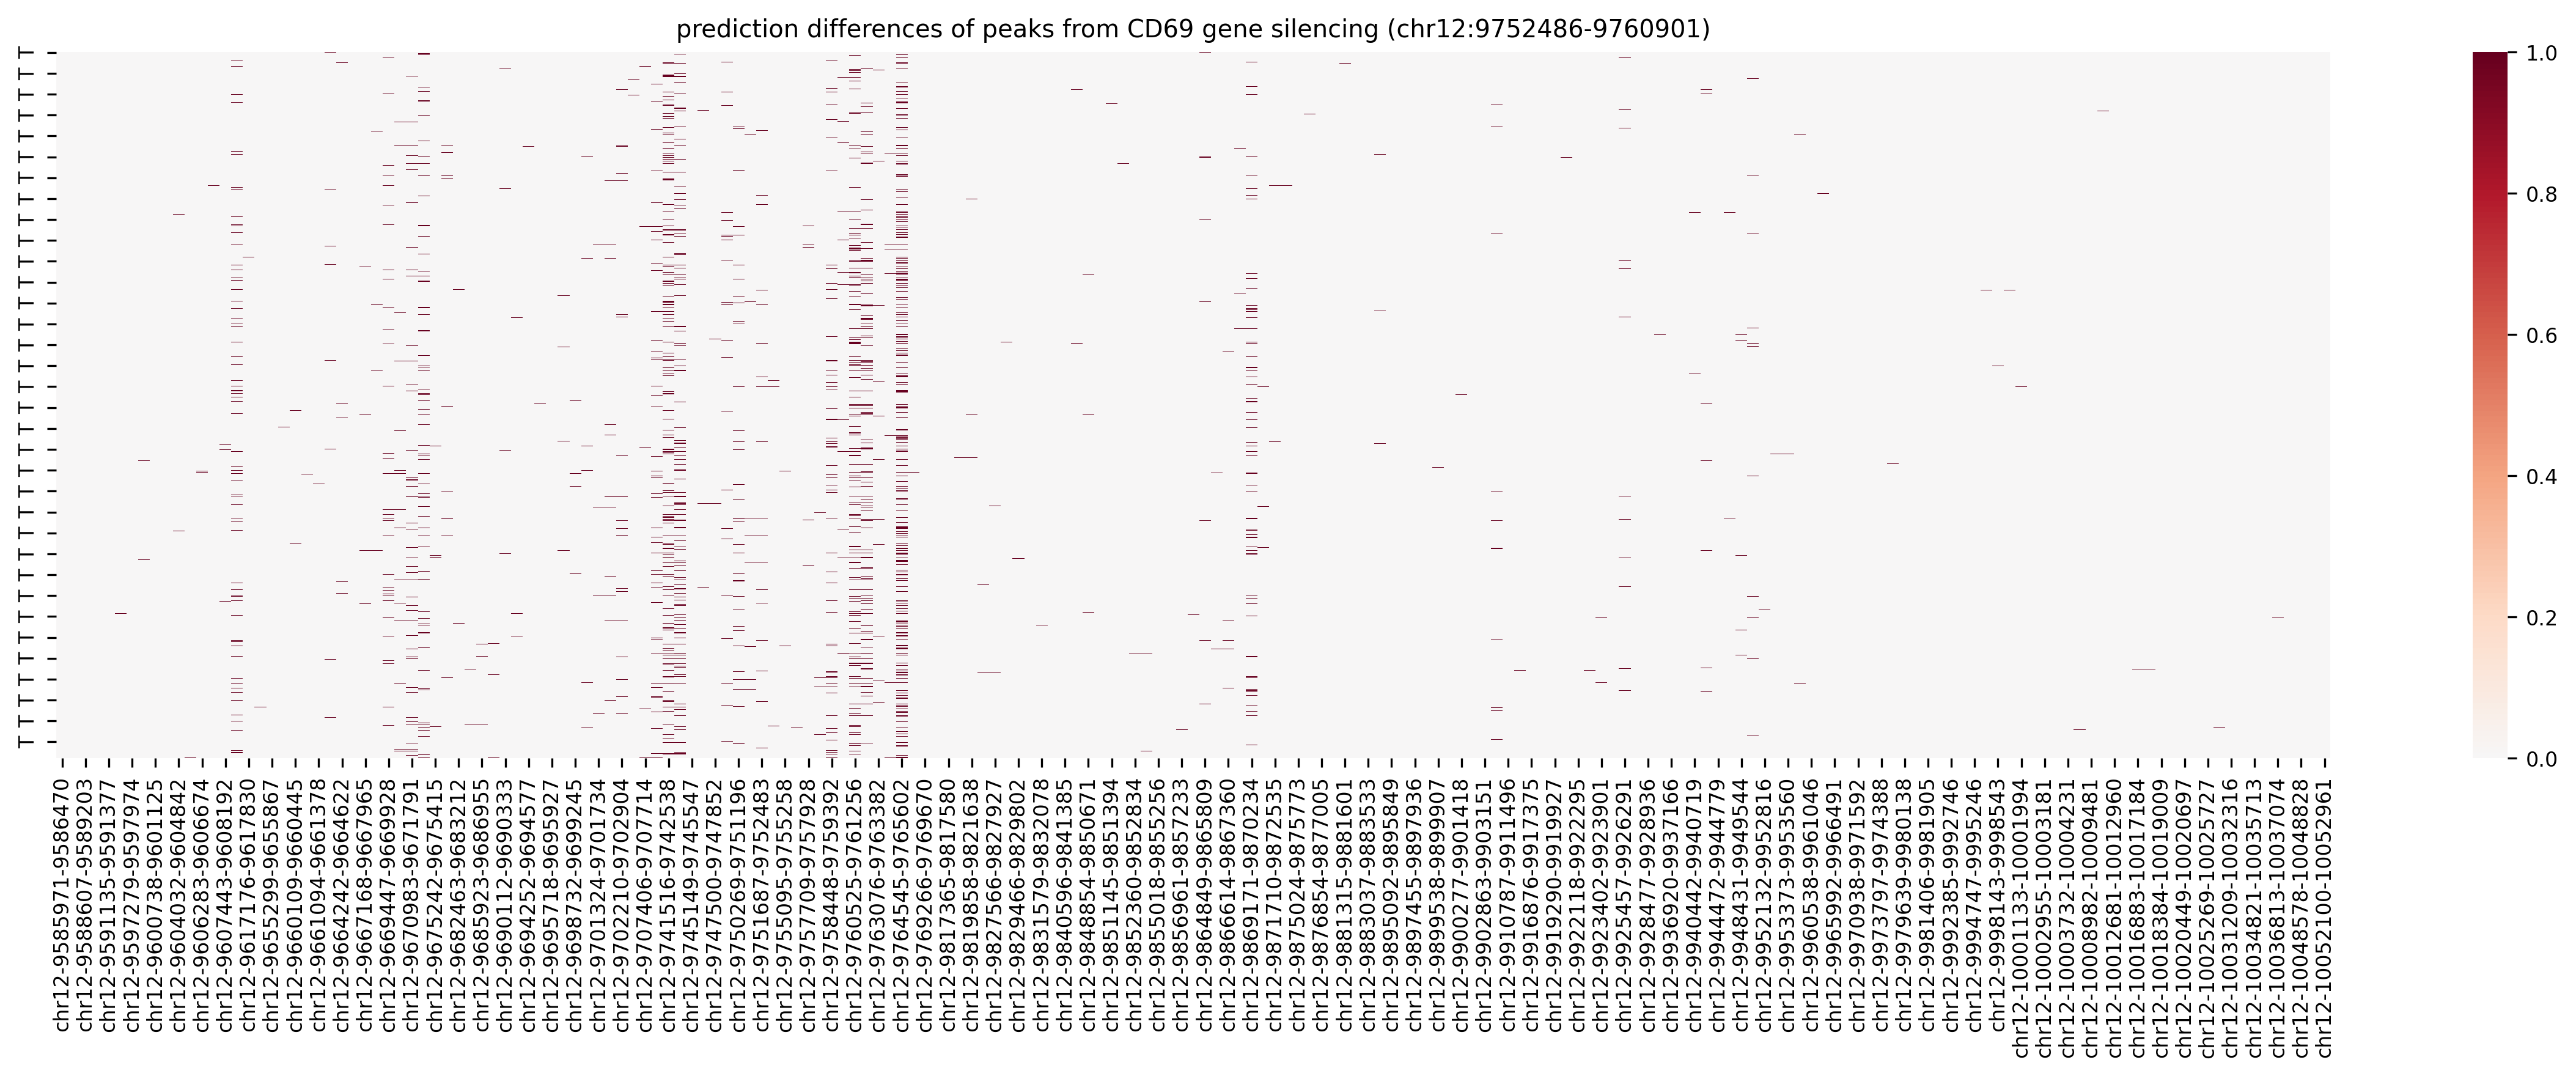

In [20]:
heatmap_control = atac_list[indices_of_interest_gene, start_peak:end_peak].X.toarray()
df_heatmap_control = plot_gel(heatmap_control, ct_as, atac_list.var_names[start_peak:end_peak], gene_name, gene_location)

In [21]:
rna_test_mat = rna_list.copy()
gene_counts = np.array(rna_test_mat.X[indices_of_interest_gene, gene_idx].todense())

for i, ct in enumerate(cell_types_unique):
    bp_location_starts, binned_kb_avg_ct, binned_kb_std_ct = gene_correlation(
        gene_counts[np.where(ct_as == ct)[0]], 
        df_heatmap_control, 
        [ct], 
        bins=df_pos_intersect*1e6, 
        window_size=window_size, 
        norm=False, 
        use_abs=True)
    df_open_closed_temp = pd.DataFrame({
        'position': bp_location_starts,
        'signal': binned_kb_avg_ct,
        'std': binned_kb_std_ct,
        'cell type': ct,
        'method': 'Spearman'
    })
    if i == 0:
        df_open_closed_control = df_open_closed_temp
    else:
        df_open_closed_control = pd.concat([df_open_closed_control, df_open_closed_temp], axis=0)

df_open_closed_control
df_open_closed_control.index = np.arange(len(df_open_closed_control))
df_open_closed_control['position'] = df_open_closed_control['position'] / 1e6
df_open_closed_control.fillna(0, inplace=True)

In [22]:
# save the dataframe
df_open_closed_control.to_csv(
    result_dir + gene_name + "_hg38_baseline_correlation.csv", index=False
)

In [23]:
df_open_closed_control

,position,signal,std,cell type,method
0,9.457404,0.000000,0.000000,T,Spearman
1,9.467404,0.000000,0.000000,T,Spearman
2,9.477404,0.000000,0.000000,T,Spearman
3,9.557404,0.000000,0.000000,T,Spearman
4,9.577404,0.000000,0.000000,T,Spearman
5,9.587404,0.009470,0.067669,T,Spearman
6,9.597404,0.009063,0.346306,T,Spearman
7,9.607404,0.019756,0.353940,T,Spearman
8,9.617404,0.003792,0.844727,T,Spearman
9,9.627404,0.000000,0.000000,T,Spearman


## Next gene: CD38

In [7]:
gene_name = "CD38"
gene_location = "chr4:15778275-15853232"
args.chr = chr = "chr4"
file_dir = preprocess_dir + "EIS_signal_" + gene_name + "_promoter.hg38.csv"
gene_id, gene_idx = get_gene_ids(gene_name)
peak_ids = find_closest_peak(gene_location, ref_df_chr4)
print(
    "Gene ID is {} at index {}, peak positions are {}".format(
        gene_id, gene_idx, peak_ids
    )
)

Gene ID is ENSG00000004468 at index 2098, peak positions are [5783, 5784, 5785, 5786, 5787, 5788, 5789, 5790, 5791, 5792, 5793, 5794, 5795, 5796, 5797, 5798, 5799, 5800, 5801, 5802, 5803, 5804, 5805, 5806, 5807, 5808, 5809, 5810, 5811, 5812, 5813, 5814, 5815, 5816, 5817, 5818, 5819, 5820, 5821, 5822, 5823, 5824]


In [8]:
#print the gene locations of the two closest peak_ids
print("The two closest peaks are located at:")
for peak_id in peak_ids:
    print(peak_id, ref_df_chr4.iloc[peak_id].values)

The two closest peaks are located at:
5783 ['chr4' 15777844 15779322]
5784 ['chr4' 15779322 15779827]
5785 ['chr4' 15779913 15780180]
5786 ['chr4' 15781539 15782174]
5787 ['chr4' 15783744 15784233]
5788 ['chr4' 15784847 15785587]
5789 ['chr4' 15786670 15787319]
5790 ['chr4' 15787689 15788379]
5791 ['chr4' 15788379 15788954]
5792 ['chr4' 15789205 15789681]
5793 ['chr4' 15789718 15789885]
5794 ['chr4' 15790268 15791933]
5795 ['chr4' 15792143 15792659]
5796 ['chr4' 15792959 15793300]
5797 ['chr4' 15793497 15794814]
5798 ['chr4' 15794814 15795433]
5799 ['chr4' 15797346 15797698]
5800 ['chr4' 15798114 15798376]
5801 ['chr4' 15798851 15799331]
5802 ['chr4' 15799510 15800399]
5803 ['chr4' 15802518 15802929]
5804 ['chr4' 15804091 15804817]
5805 ['chr4' 15805501 15806129]
5806 ['chr4' 15806129 15806865]
5807 ['chr4' 15807046 15807815]
5808 ['chr4' 15808730 15809811]
5809 ['chr4' 15811567 15812538]
5810 ['chr4' 15814789 15815288]
5811 ['chr4' 15817684 15817960]
5812 ['chr4' 15832354 15833490]
58

### perturbation

In [ ]:
device = accelerator.device
chr = 'chr4'
atac_list = ad.read_h5ad(data_dir + f"/atac_data/atac_{chr}_independence_t_cell.h5ad")
gene_ensembl, _ = get_gene_ids(gene_name)
PRETRAIN_VERSION = '20230926_85M'
cellplm = load_pretrain(PRETRAIN_VERSION, model_dir)

peak_count = len(peaks_chr4)
rna_batch = sparse_scipy_to_tensor(csr_matrix(rna_list.X.astype(float)))
_, ff_idx = train_test_split(range(len(rna_list)), test_size=0.1, random_state=args.seed)
ffset = torch.utils.data.TensorDataset(torch.IntTensor(ff_idx))
_ff = torch.utils.data.DataLoader(ffset, batch_size=args.batch_size, num_workers=4)
model = ATACformer(args, cellplm, gene_list, peak_size=peak_count)
model = load_model(model, args, chr).to(device)
model = finetune_batch_embedding(model, len(uniques), _ff, rna_batch, batch_int, device, args.lr*0.1)
for param in model.parameters():
    param.requires_grad = False

accelerator.print(f"****************perturb gene {gene_name}")
indices_of_interest_gene = np.nonzero(rna_list[:, gene_ensembl].X.toarray())[0]  # record non-zero cell index given gene in rna matrix
if len(indices_of_interest_gene) == 0:
    raise ValueError("no cell for perturbation")
else:
    print("indices_of_interest_gene:", len(indices_of_interest_gene))
rna_test_mat = rna_list[indices_of_interest_gene].copy()
rna_test_original = sparse_scipy_to_tensor(csr_matrix(rna_test_mat.X.astype(float)))
batch_test = torch.tensor(batch_int[indices_of_interest_gene], dtype=torch.int).flatten()
testset = torch.utils.data.TensorDataset(torch.IntTensor(range(len(rna_test_mat))))
_test = torch.utils.data.DataLoader(testset, batch_size=args.batch_size)

# raw prediction without perturbation
print("load model")
predictions_raw = evaluate_perturbation(model, _test, rna_test_original, batch_test, device)
print("predictions_perturb shape:", predictions_raw.shape)
torch.cuda.empty_cache()

predictions_perturb = simulate_perturbation(model, _test, rna_test_mat, rna_test_original, batch_test, gene_ensembl, gene_list, device, lr=args.lr)
print("predictions_perturb shape:", predictions_perturb.shape)
predicted_changes = predictions_perturb - predictions_raw  # δX for non-zero cell

/tmp/ipykernel_726704/801771895.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))
/pool1/yuliyi/program/ATACformer/src/pertur

****************perturb gene CD38
indices_of_interest_gene: 165
load model
predictions_perturb shape: (165, 48861)


/home/yuliyi/anaconda3/envs/pyt/lib/python3.9/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


predictions_perturb shape: (165, 48861)


### analyse

In [10]:
window_length = 900000
gene_chromosome = gene_location.split(":")[0]
window_start = int(gene_location.split(":")[1].split("-")[0]) - window_length
window_end = int(gene_location.split(":")[1].split("-")[1]) + window_length
# find the closest start and end peaks to the window start and end
start_peak, end_peak = find_closest_start_and_end(gene_chromosome, window_start, window_end, ref_df_chr4)

cell_types = celltype[indices_of_interest_gene]
ct_as = ct_a[indices_of_interest_gene]
heatmap_1 = predicted_changes[:,start_peak:end_peak]

df_heatmap_1 = plot_gel(heatmap_1, ct_as, atac_list.var_names[start_peak:end_peak], gene_name, gene_location) #because it looks like a gel

In [11]:
cell_types_stat = df_heatmap_1.index.value_counts()
cell_types_unique = cell_types_stat.index.values
cell_types_stat

T    165
Name: count, dtype: int64

In [12]:
window_size = 10000

df_hichip = prepare_df_emma(file_dir)
df_pos_intersect = np.sort(df_hichip['position'].unique())

for i, ct in enumerate(cell_types_unique):
    bp_location_starts, binned_kb_avg_ct, binned_kb_std_ct = insilico_hichip(df_heatmap_1, [ct], bins=df_pos_intersect, window_size=window_size, norm=False, use_abs=True)
    df_open_closed_temp = pd.DataFrame({
        'position': bp_location_starts,
        'signal': binned_kb_avg_ct,
        'std': binned_kb_std_ct,
        'cell type': ct,
        'method': 'epiGen'
    })
    if i == 0:
        df_open_closed = df_open_closed_temp
    else:
        df_open_closed = pd.concat([df_open_closed, df_open_closed_temp], axis=0)

df_open_closed = pd.concat([df_open_closed, df_hichip], axis=0)
df_open_closed['position'] = df_open_closed['position'].values / 1e6
df_open_closed = df_open_closed.reset_index(drop=True)
# save the dataframe
df_open_closed.to_csv(
    result_dir + gene_name + "_hg38_hichip_epiGen_aligned_locations.csv", index=False
)
df_open_closed

/tmp/ipykernel_726704/257098763.py:178: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_neg["sample_name"] = "negative"
/tmp/ipykernel_726704/257098763.py:99: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  binned_kb_avg.append(abs(df_cell_avg[i]))
/tmp/ipykernel_726704/257098763.py:102: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  binned_kb_std.append(df_cell_std[i])
/tmp/ipyk

,position,signal,std,cell type,method
0,14.878376,0.000000,0.0,T,epiGen
1,14.908376,0.000000,0.0,T,epiGen
2,14.918376,0.000000,0.0,T,epiGen
3,14.938376,0.000000,0.0,T,epiGen
4,14.948376,0.000000,0.0,T,epiGen
...,...,...,...,...,...
311,16.238377,0.231158,0.0,negative,HiChIP
312,16.258377,0.462317,0.0,negative,HiChIP
313,16.268377,0.231158,0.0,negative,HiChIP
314,16.288377,0.231158,0.0,negative,HiChIP


### baseline correlation

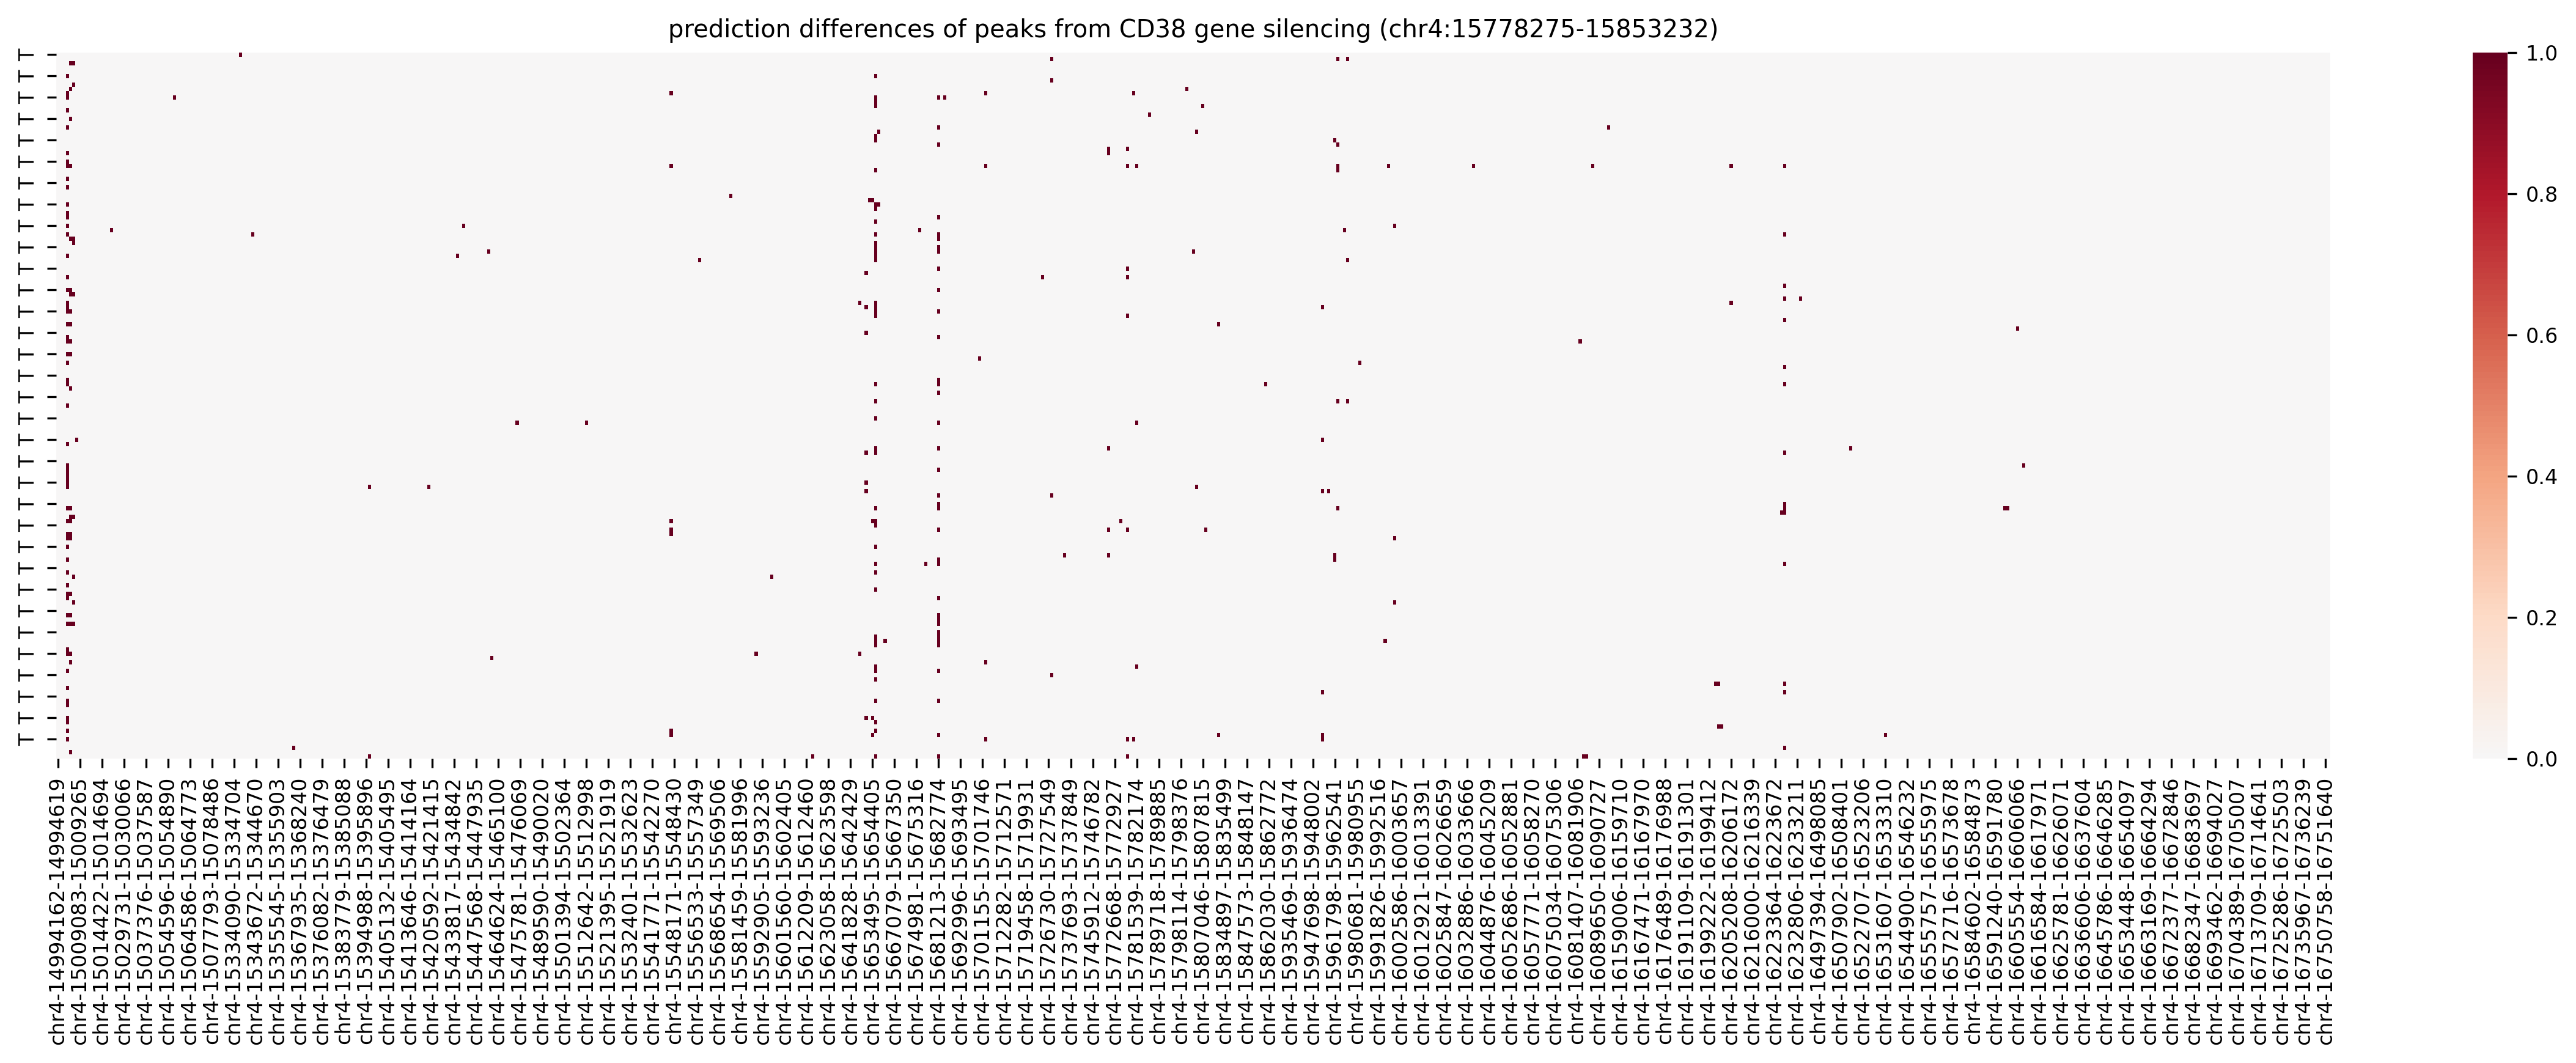

In [34]:
heatmap_control = atac_list[indices_of_interest_gene, start_peak:end_peak].X.toarray()
df_heatmap_control = plot_gel(heatmap_control, ct_as, atac_list.var_names[start_peak:end_peak], gene_name, gene_location)

In [35]:
rna_test_mat = rna_list.copy()
gene_counts = np.array(rna_test_mat.X[indices_of_interest_gene, gene_idx].todense())

for i, ct in enumerate(cell_types_unique):
    bp_location_starts, binned_kb_avg_ct, binned_kb_std_ct = gene_correlation(
        gene_counts[np.where(ct_as == ct)[0]], 
        df_heatmap_control, 
        [ct], 
        bins=df_pos_intersect*1e6, 
        window_size=window_size, 
        norm=False, 
        use_abs=True)
    df_open_closed_temp = pd.DataFrame({
        'position': bp_location_starts,
        'signal': binned_kb_avg_ct,
        'std': binned_kb_std_ct,
        'cell type': ct,
        'method': 'Spearman'
    })
    if i == 0:
        df_open_closed_control = df_open_closed_temp
    else:
        df_open_closed_control = pd.concat([df_open_closed_control, df_open_closed_temp], axis=0)

df_open_closed_control
df_open_closed_control.index = np.arange(len(df_open_closed_control))
df_open_closed_control['position'] = df_open_closed_control['position'] / 1e6
df_open_closed_control.fillna(0, inplace=True)

In [36]:
# save the dataframe
df_open_closed_control.to_csv(
    result_dir + gene_name + "_hg38_baseline_correlation.csv", index=False
)

## New gene: IL7R

In [7]:
gene_name = "IL7R"
gene_location = "chr5:35852695-35879603"

file_dir = preprocess_dir + "EIS_signal_" + gene_name + "_promoter.hg38.csv"
gene_id, gene_idx = get_gene_ids(gene_name)
peak_ids = find_closest_peak(gene_location, ref_df_chr5)
print(
    "Gene ID is {} at index {}, peak positions are {}".format(
        gene_id, gene_idx, peak_ids
    )
)

Gene ID is ENSG00000168685 at index 6051, peak positions are [7717, 7718, 7719, 7720, 7721, 7722, 7723, 7724, 7725, 7726, 7727, 7728, 7729, 7730, 7731, 7732, 7733, 7734, 7735, 7736]


In [8]:
#print the gene locations of the closest peak_ids
print("The closest peaks are located at:")
for peak_id in peak_ids:
    print(peak_id, ref_df_chr5.iloc[peak_id].values)

The closest peaks are located at:
7717 ['chr5' 35852448 35853193]
7718 ['chr5' 35853193 35854248]
7719 ['chr5' 35854248 35854877]
7720 ['chr5' 35855194 35855626]
7721 ['chr5' 35856005 35856290]
7722 ['chr5' 35856487 35857564]
7723 ['chr5' 35857564 35858436]
7724 ['chr5' 35858850 35859931]
7725 ['chr5' 35860649 35861237]
7726 ['chr5' 35861610 35862202]
7727 ['chr5' 35862202 35862510]
7728 ['chr5' 35863039 35863721]
7729 ['chr5' 35865907 35866150]
7730 ['chr5' 35868482 35869294]
7731 ['chr5' 35869416 35870504]
7732 ['chr5' 35870558 35871203]
7733 ['chr5' 35875454 35875953]
7734 ['chr5' 35876261 35876812]
7735 ['chr5' 35876812 35877454]
7736 ['chr5' 35877454 35878173]


### perturbation

In [ ]:
device = accelerator.device
chr = 'chr5'
atac_list = ad.read_h5ad(data_dir + f"/atac_data/atac_{chr}_independence_t_cell.h5ad")
gene_ensembl, _ = get_gene_ids(gene_name)
PRETRAIN_VERSION = '20230926_85M'
cellplm = load_pretrain(PRETRAIN_VERSION, model_dir)

peak_count = len(peaks_chr5)
rna_batch = sparse_scipy_to_tensor(csr_matrix(rna_list.X.astype(float)))
_, ff_idx = train_test_split(range(len(rna_list)), test_size=0.1, random_state=args.seed)
ffset = torch.utils.data.TensorDataset(torch.IntTensor(ff_idx))
_ff = torch.utils.data.DataLoader(ffset, batch_size=args.batch_size, num_workers=4)
model = ATACformer(args, cellplm, gene_list, peak_size=peak_count)
model = load_model(model, args, chr).to(device)
model = finetune_batch_embedding(model, len(uniques), _ff, rna_batch, batch_int, device, args.lr*0.1)
for param in model.parameters():
    param.requires_grad = False

accelerator.print(f"****************perturb gene {gene_name}")
indices_of_interest_gene = np.nonzero(rna_list[:, gene_ensembl].X.toarray())[0]  # record non-zero cell index given gene in rna matrix
if len(indices_of_interest_gene) == 0:
    raise ValueError("no cell for perturbation")
else:
    print("indices_of_interest_gene:", len(indices_of_interest_gene))
rna_test_mat = rna_list[indices_of_interest_gene].copy()
rna_test_original = sparse_scipy_to_tensor(csr_matrix(rna_test_mat.X.astype(float)))
batch_test = torch.tensor(batch_int[indices_of_interest_gene], dtype=torch.int).flatten()
testset = torch.utils.data.TensorDataset(torch.IntTensor(range(len(rna_test_mat))))
_test = torch.utils.data.DataLoader(testset, batch_size=args.batch_size)

# raw prediction without perturbation
print("load model")
predictions_raw = evaluate_perturbation(model, _test, rna_test_original, batch_test, device)
print("predictions_perturb shape:", predictions_raw.shape)
torch.cuda.empty_cache()

predictions_perturb = simulate_perturbation(model, _test, rna_test_mat, rna_test_original, batch_test, gene_ensembl, gene_list, device, lr=args.lr)
print("predictions_perturb shape:", predictions_perturb.shape)
predicted_changes = predictions_perturb - predictions_raw  # δX for non-zero cell

/tmp/ipykernel_460085/1528270738.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))
/pool1/yuliyi/program/ATACformer/src/pertu

****************perturb gene IL7R
indices_of_interest_gene: 1482
load model
predictions_perturb shape: (1482, 50481)


/home/yuliyi/anaconda3/envs/pyt/lib/python3.9/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


predictions_perturb shape: (1482, 50481)


### analysis

In [10]:
window_length = 500000
gene_chromosome = gene_location.split(":")[0]
window_start = int(gene_location.split(":")[1].split("-")[0]) - window_length
window_end = int(gene_location.split(":")[1].split("-")[1]) + window_length
# find the closest start and end peaks to the window start and end
start_peak, end_peak = find_closest_start_and_end(gene_chromosome, window_start, window_end, ref_df_chr5)

cell_types = celltype[indices_of_interest_gene]
ct_as = ct_a[indices_of_interest_gene]
heatmap_1 = predicted_changes[:,start_peak:end_peak]

df_heatmap_1 = plot_gel(heatmap_1, ct_as, atac_list.var_names[start_peak:end_peak], gene_name, gene_location) #because it looks like a gel

In [11]:
cell_types_stat = df_heatmap_1.index.value_counts()
cell_types_unique = cell_types_stat.index.values
cell_types_stat

T    1482
Name: count, dtype: int64

In [12]:
# plot the response in emma's window per cell type

window_size = 10000

df_hichip = prepare_df_emma(file_dir)
df_pos_intersect = np.sort(df_hichip['position'].unique())

for i, ct in enumerate(cell_types_unique):
    bp_location_starts, binned_kb_avg_ct, binned_kb_std_ct = insilico_hichip(df_heatmap_1, [ct], bins=df_pos_intersect, window_size=window_size, norm=False, use_abs=True)
    df_open_closed_temp = pd.DataFrame({
        'position': bp_location_starts,
        'signal': binned_kb_avg_ct,
        'std': binned_kb_std_ct,
        'cell type': ct,
        'method': 'epiGen'
    })
    if i == 0:
        df_open_closed = df_open_closed_temp
    else:
        df_open_closed = pd.concat([df_open_closed, df_open_closed_temp], axis=0)

df_open_closed = pd.concat([df_open_closed, df_hichip], axis=0)
df_open_closed['position'] = df_open_closed['position'].values / 1e6
df_open_closed = df_open_closed.reset_index(drop=True)
# save the dataframe
df_open_closed.to_csv(
    result_dir + gene_name + "_hg38_hichip_epiGen_aligned_locations.csv", index=False
)
df_open_closed

/tmp/ipykernel_460085/257098763.py:178: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_neg["sample_name"] = "negative"
/tmp/ipykernel_460085/257098763.py:99: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  binned_kb_avg.append(abs(df_cell_avg[i]))
/tmp/ipykernel_460085/257098763.py:102: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  binned_kb_std.append(df_cell_std[i])
/tmp/ipyk

,position,signal,std,cell type,method
0,35.359898,0.000000,0.0,T,epiGen
1,35.369898,0.000000,0.0,T,epiGen
2,35.379898,0.000000,0.0,T,epiGen
3,35.389898,0.000000,0.0,T,epiGen
4,35.409898,0.000000,0.0,T,epiGen
...,...,...,...,...,...
233,36.199898,0.173704,0.0,negative,HiChIP
234,36.229898,0.173704,0.0,negative,HiChIP
235,36.239898,1.215925,0.0,negative,HiChIP
236,36.299898,0.347407,0.0,negative,HiChIP


### baseline correlation

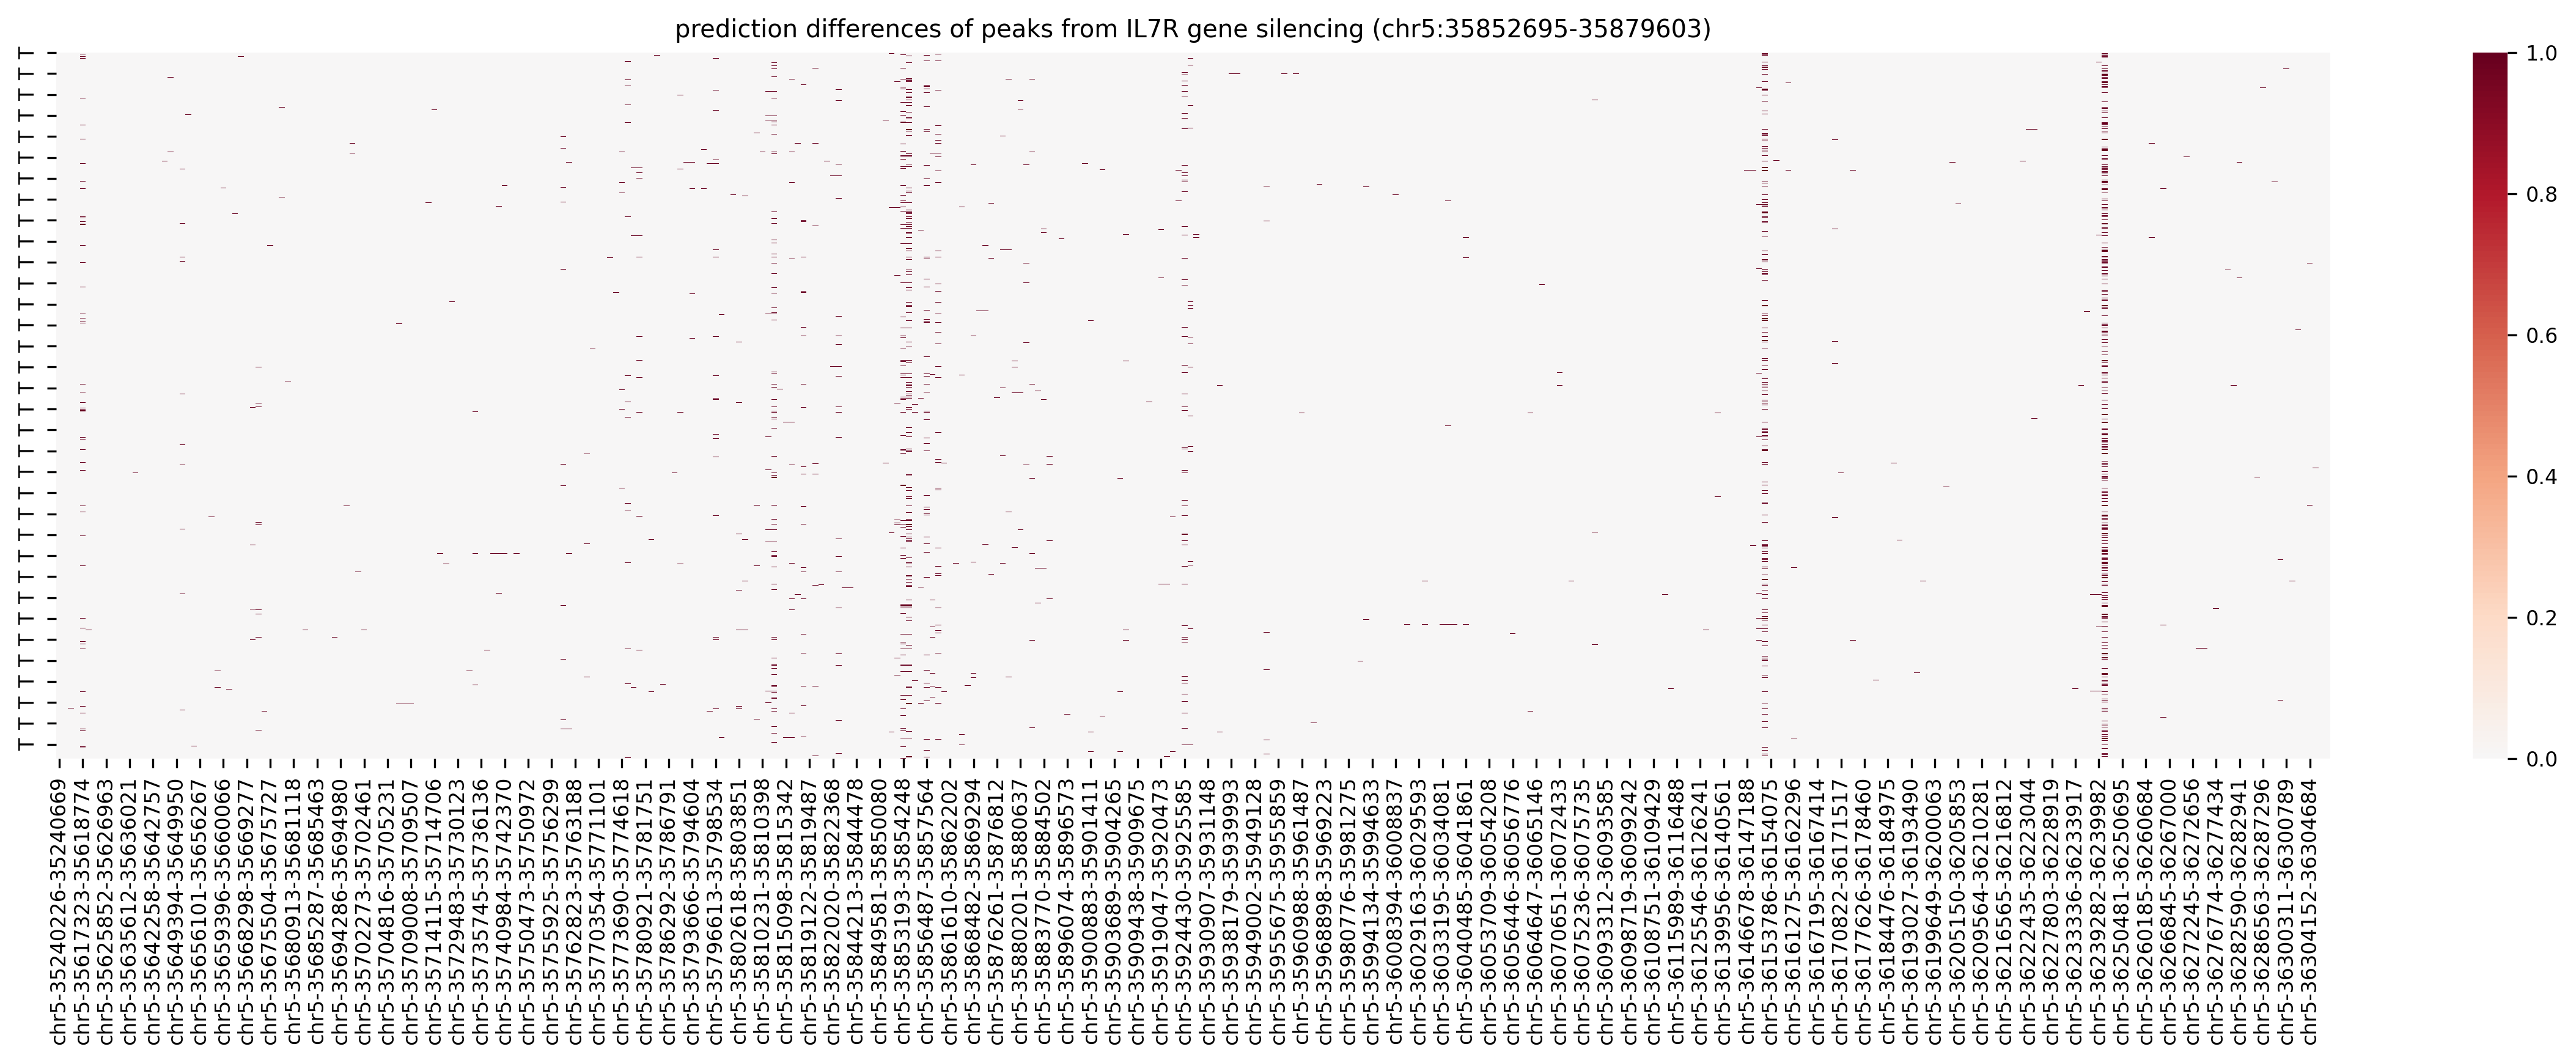

In [47]:
heatmap_control = atac_list[indices_of_interest_gene, start_peak:end_peak].X.toarray()
df_heatmap_control = plot_gel(heatmap_control, ct_as, atac_list.var_names[start_peak:end_peak], gene_name, gene_location)

In [50]:
rna_test_mat = rna_list.copy()
gene_counts = np.array(rna_test_mat.X[indices_of_interest_gene, gene_idx].todense())

for i, ct in enumerate(cell_types_unique):
    bp_location_starts, binned_kb_avg_ct, binned_kb_std_ct = gene_correlation(
        gene_counts[np.where(ct_as == ct)[0]], 
        df_heatmap_control, 
        [ct], 
        bins=df_pos_intersect*1e6, 
        window_size=window_size, 
        norm=False, 
        use_abs=True)
    df_open_closed_temp = pd.DataFrame({
        'position': bp_location_starts,
        'signal': binned_kb_avg_ct,
        'std': binned_kb_std_ct,
        'cell type': ct,
        'method': 'Spearman'
    })
    if i == 0:
        df_open_closed_control = df_open_closed_temp
    else:
        df_open_closed_control = pd.concat([df_open_closed_control, df_open_closed_temp], axis=0)

df_open_closed_control
df_open_closed_control.index = np.arange(len(df_open_closed_control))
df_open_closed_control['position'] = df_open_closed_control['position'] / 1e6
df_open_closed_control.fillna(0, inplace=True)

In [51]:
# save the dataframe
df_open_closed_control.to_csv(
    result_dir + gene_name + "_hg38_baseline_correlation.csv", index=False
)

## Next gene: IRF4

In [7]:
# define the gene of interest and its location
gene_name = "IRF4"
gene_location = "chr6:391739-411443"

# load the ground truth data (experimental HiChIP)
file_dir = preprocess_dir + "EIS_signal_" + gene_name + "_promoter.hg38.csv"
# define where the gene of interest is in the data (and its location)
gene_id, gene_idx = get_gene_ids(gene_name)
peak_ids = find_closest_peak(gene_location, ref_df_chr6)
print(
    "Gene ID is {} at index {}, peak positions are {}".format(
        gene_id, gene_idx, peak_ids
    )
)

Gene ID is ENSG00000137265 at index 6164, peak positions are [83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]


In [8]:
#print the gene locations of the two closest peak_ids (to see whether the data even covers the gene)
print("The closest peaks are located at:")
for peak_id in peak_ids:
    print(peak_id, ref_df_chr6.iloc[peak_id].values)

The closest peaks are located at:
83 ['chr6' 390852 392538]
84 ['chr6' 392538 393733]
85 ['chr6' 393733 394314]
86 ['chr6' 394565 395064]
87 ['chr6' 395776 396062]
88 ['chr6' 396624 397096]
89 ['chr6' 398655 399209]
90 ['chr6' 399706 400405]
91 ['chr6' 401160 402051]
92 ['chr6' 402936 403773]
93 ['chr6' 403773 404555]
94 ['chr6' 404643 405438]
95 ['chr6' 408206 409255]
96 ['chr6' 409428 409760]
97 ['chr6' 409900 410280]
98 ['chr6' 410280 411249]
99 ['chr6' 411249 411804]


### perturbation

In [ ]:
device = accelerator.device
chr = 'chr6'
atac_list = ad.read_h5ad(data_dir + f"/atac_data/atac_{chr}_independence_t_cell.h5ad")
gene_ensembl, _ = get_gene_ids(gene_name)
PRETRAIN_VERSION = '20230926_85M'
cellplm = load_pretrain(PRETRAIN_VERSION, model_dir)

peak_count = len(peaks_chr6)
rna_batch = sparse_scipy_to_tensor(csr_matrix(rna_list.X.astype(float)))
_, ff_idx = train_test_split(range(len(rna_list)), test_size=0.1, random_state=args.seed)
ffset = torch.utils.data.TensorDataset(torch.IntTensor(ff_idx))
_ff = torch.utils.data.DataLoader(ffset, batch_size=args.batch_size, num_workers=4)
model = ATACformer(args, cellplm, gene_list, peak_size=peak_count)
model = load_model(model, args, chr).to(device)
model = finetune_batch_embedding(model, len(uniques), _ff, rna_batch, batch_int, device, args.lr*0.1)
for param in model.parameters():
    param.requires_grad = False

accelerator.print(f"****************perturb gene {gene_name}")
indices_of_interest_gene = np.nonzero(rna_list[:, gene_ensembl].X.toarray())[0]  # record non-zero cell index given gene in rna matrix
if len(indices_of_interest_gene) == 0:
    raise ValueError("no cell for perturbation")
else:
    print("indices_of_interest_gene:", len(indices_of_interest_gene))
rna_test_mat = rna_list[indices_of_interest_gene].copy()
rna_test_original = sparse_scipy_to_tensor(csr_matrix(rna_test_mat.X.astype(float)))
batch_test = torch.tensor(batch_int[indices_of_interest_gene], dtype=torch.int).flatten()
testset = torch.utils.data.TensorDataset(torch.IntTensor(range(len(rna_test_mat))))
_test = torch.utils.data.DataLoader(testset, batch_size=args.batch_size)

# raw prediction without perturbation
print("load model")
predictions_raw = evaluate_perturbation(model, _test, rna_test_original, batch_test, device)
print("predictions_perturb shape:", predictions_raw.shape)
torch.cuda.empty_cache()

predictions_perturb = simulate_perturbation(model, _test, rna_test_mat, rna_test_original, batch_test, gene_ensembl, gene_list, device, lr=args.lr)
print("predictions_perturb shape:", predictions_perturb.shape)
predicted_changes = predictions_perturb - predictions_raw  # δX for non-zero cell

/tmp/ipykernel_478198/1528270738.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))
/pool1/yuliyi/program/ATACformer/src/pertu

****************perturb gene IRF4
indices_of_interest_gene: 46
load model
predictions_perturb shape: (46, 52327)


/home/yuliyi/anaconda3/envs/pyt/lib/python3.9/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


predictions_perturb shape: (46, 52327)


### analysis

In [10]:
window_length = 200000
gene_chromosome = gene_location.split(":")[0]
window_start = int(gene_location.split(":")[1].split("-")[0]) - window_length
window_end = int(gene_location.split(":")[1].split("-")[1]) + window_length
# find the closest start and end peaks to the window start and end
start_peak, end_peak = find_closest_start_and_end(gene_chromosome, window_start, window_end, ref_df_chr6)

cell_types = celltype[indices_of_interest_gene]
ct_as = ct_a[indices_of_interest_gene]
heatmap_1 = predicted_changes[:,start_peak:end_peak]

df_heatmap_1 = plot_gel(heatmap_1, ct_as, atac_list.var_names[start_peak:end_peak], gene_name, gene_location) #because it looks like a gel

In [11]:
cell_types_stat = df_heatmap_1.index.value_counts()
cell_types_unique = cell_types_stat.index.values
cell_types_stat

T    46
Name: count, dtype: int64

In [12]:
# plot the response in emma's window per cell type
# so that we can compare to ground truth
# this just makes the peak windows the same

window_size = 10000

df_hichip = prepare_df_emma(file_dir)
df_pos_intersect = np.sort(df_hichip['position'].unique())

for i, ct in enumerate(cell_types_unique):
    bp_location_starts, binned_kb_avg_ct, binned_kb_std_ct = insilico_hichip(df_heatmap_1, [ct], bins=df_pos_intersect, window_size=window_size, norm=False, use_abs=True)
    df_open_closed_temp = pd.DataFrame({
        'position': bp_location_starts,
        'signal': binned_kb_avg_ct,
        'std': binned_kb_std_ct,
        'cell type': ct,
        'method': 'epiGen'
    })
    if i == 0:
        df_open_closed = df_open_closed_temp
    else:
        df_open_closed = pd.concat([df_open_closed, df_open_closed_temp], axis=0)

df_open_closed = pd.concat([df_open_closed, df_hichip], axis=0)
df_open_closed['position'] = df_open_closed['position'].values / 1e6
# reindex from 0
df_open_closed = df_open_closed.reset_index(drop=True)
# save the dataframe
df_open_closed.to_csv(
    result_dir + gene_name + "_hg38_hichip_epiGen_aligned_locations.csv", index=False
)
df_open_closed

/tmp/ipykernel_478198/257098763.py:178: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_neg["sample_name"] = "negative"
/tmp/ipykernel_478198/257098763.py:99: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  binned_kb_avg.append(abs(df_cell_avg[i]))
/tmp/ipykernel_478198/257098763.py:102: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  binned_kb_std.append(df_cell_std[i])
/tmp/ipyk

,position,signal,std,cell type,method
0,0.20,0.000000,0.0,T,epiGen
1,0.21,0.000000,0.0,T,epiGen
2,0.22,0.000000,0.0,T,epiGen
3,0.23,0.000000,0.0,T,epiGen
4,0.24,0.000000,0.0,T,epiGen
...,...,...,...,...,...
103,0.50,0.316918,0.0,negative,HiChIP
104,0.52,0.105639,0.0,negative,HiChIP
105,0.54,0.105639,0.0,negative,HiChIP
106,0.55,0.105639,0.0,negative,HiChIP


### baseline correlation

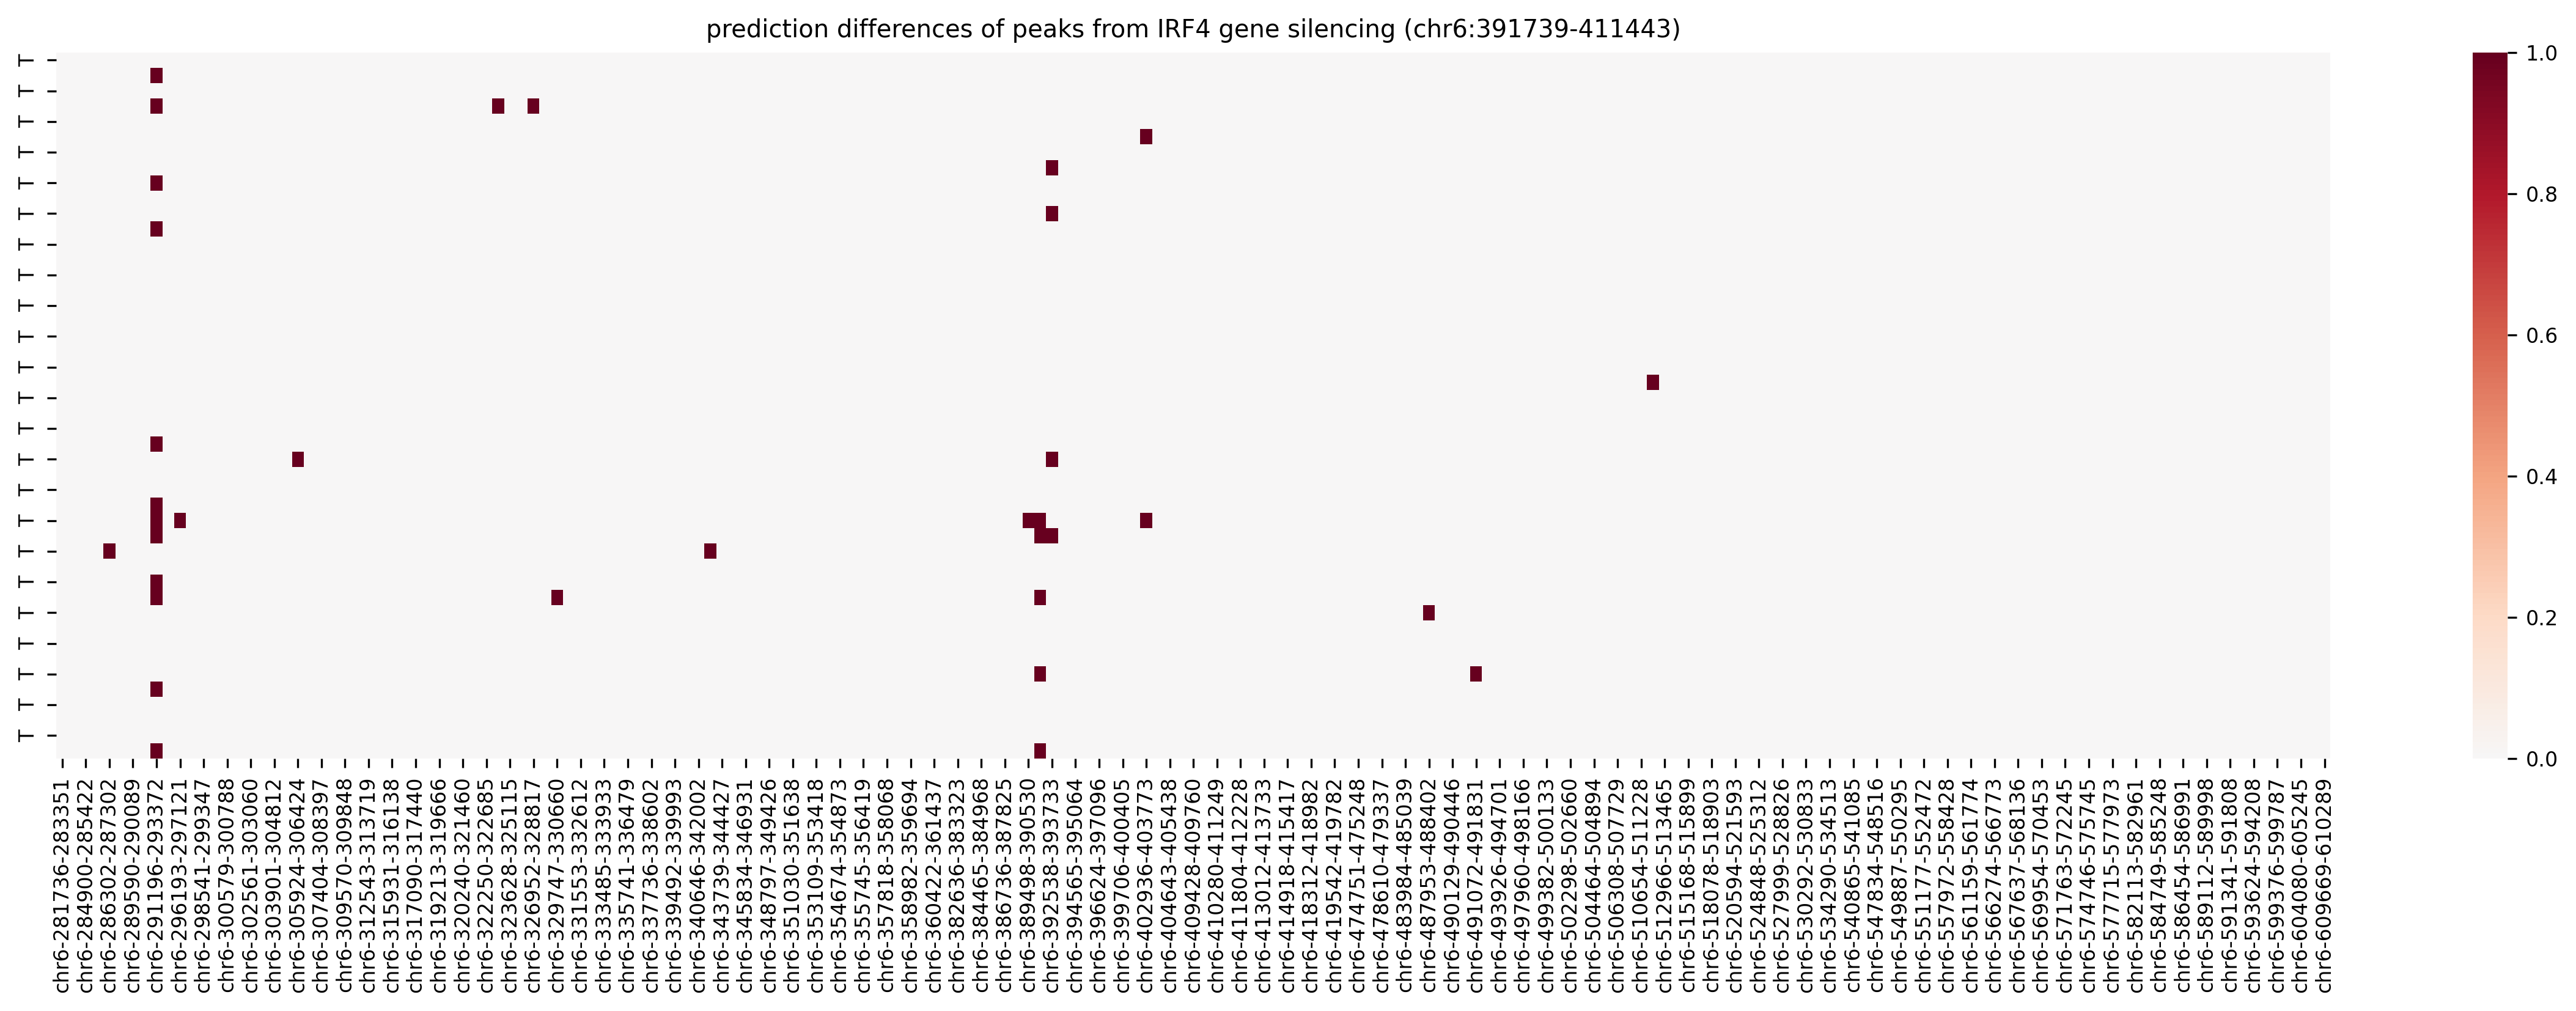

In [62]:
heatmap_control = atac_list[indices_of_interest_gene, start_peak:end_peak].X.toarray()
df_heatmap_control = plot_gel(heatmap_control, ct_as, atac_list.var_names[start_peak:end_peak], gene_name, gene_location)

In [63]:
rna_test_mat = rna_list.copy()
gene_counts = np.array(rna_test_mat.X[indices_of_interest_gene, gene_idx].todense())

for i, ct in enumerate(cell_types_unique):
    bp_location_starts, binned_kb_avg_ct, binned_kb_std_ct = gene_correlation(
        gene_counts[np.where(ct_as == ct)[0]], 
        df_heatmap_control, 
        [ct], 
        bins=df_pos_intersect*1e6, 
        window_size=window_size, 
        norm=False, 
        use_abs=True)
    df_open_closed_temp = pd.DataFrame({
        'position': bp_location_starts,
        'signal': binned_kb_avg_ct,
        'std': binned_kb_std_ct,
        'cell type': ct,
        'method': 'Spearman'
    })
    if i == 0:
        df_open_closed_control = df_open_closed_temp
    else:
        df_open_closed_control = pd.concat([df_open_closed_control, df_open_closed_temp], axis=0)

df_open_closed_control
df_open_closed_control.index = np.arange(len(df_open_closed_control))
df_open_closed_control['position'] = df_open_closed_control['position'] / 1e6
df_open_closed_control.fillna(0, inplace=True)

In [64]:
# save the dataframe
df_open_closed_control.to_csv(
    result_dir + gene_name + "_hg38_baseline_correlation.csv", index=False
)